In [1]:
# dependencies
!pip install torch torchvision torchaudio -q
!pip install pandas numpy matplotlib seaborn -q
!pip install nltk -q
!pip install bert-score -q
!pip install sentencepiece -q
!pip install tqdm -q

In [2]:
import os
import re
import math
import time
import random
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from bert_score import score

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", DEVICE)

Using Device: cuda


In [3]:

train_sa = pd.read_csv("train_sa_10000 (1).csv")
train_en = pd.read_csv("train_en_10000 (1).csv")

dev_sa = pd.read_csv("dev_sa_1000 (1).csv")
dev_en = pd.read_csv("dev_en_1000 (1).csv")

test_sa = pd.read_csv("test_sa_1000 (1).csv")

try:
    test_en = pd.read_csv("test_en_1000 (1).csv")
    HAS_TEST_GOLD = True
    print("test_en.csv found — will report BLEU/BERTScore on the test set too.")
except FileNotFoundError:
    test_en = None
    HAS_TEST_GOLD = False
    print("test_en.csv not found — will only generate predictions (no test-set metrics).")

print("train_sa:", train_sa.shape, "| train_en:", train_en.shape)
print("dev_sa  :", dev_sa.shape,   "| dev_en  :", dev_en.shape)
print("test_sa :", test_sa.shape)

test_en.csv found — will report BLEU/BERTScore on the test set too.
train_sa: (10000, 2) | train_en: (10000, 2)
dev_sa  : (1000, 2) | dev_en  : (1000, 2)
test_sa : (1000, 2)


In [4]:
train = train_sa.merge(train_en, on="Source_id")
dev = dev_sa.merge(dev_en, on="Source_id")

if HAS_TEST_GOLD:
    test = test_sa.merge(test_en, on="Source_id")
else:
    test = test_sa.copy()

train.head()

,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [5]:
print("Training missing values:\n", train.isnull().sum())
print("\nDev missing values:\n", dev.isnull().sum())
print("\nTest missing values:\n", test.isnull().sum())

Training missing values:
 Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64

Dev missing values:
 Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64

Test missing values:
 Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64


In [6]:
train = train.dropna().reset_index(drop=True)
dev = dev.dropna().reset_index(drop=True)
test = test.dropna().reset_index(drop=True)

print(train.shape, dev.shape, test.shape)

(10000, 3) (1000, 3) (1000, 3)


In [7]:
train.columns = ["id", "sanskrit", "english"]
dev.columns = ["id", "sanskrit", "english"]
test.columns = ["id", "sanskrit", "english"] if HAS_TEST_GOLD else ["id", "sanskrit"]

train.head()

,id,sanskrit,english
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [8]:
for i in range(5):
    print("Sanskrit :", train.iloc[i]["sanskrit"])
    print("English  :", train.iloc[i]["english"])
    print("-" * 80)

Sanskrit : "Ctrl, S नुत्वा रक्षन्तु।"
English  : Save it with Ctrl, S.
--------------------------------------------------------------------------------
Sanskrit : गुरुः छात्रान् एकवारं पाठयति ।
English  : Teacher will teach the students only once.
--------------------------------------------------------------------------------
Sanskrit : चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित्रद्वयं स्वीकरणीयमस्ति । इदमतीव सुलभमस्ति ।
English  : To recreate this animation, I have to take two images out of this stack which is very easy.
--------------------------------------------------------------------------------
Sanskrit : वयं  Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।
English  : I will choose Colors options by clicking on it.
--------------------------------------------------------------------------------
Sanskrit : "अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत्वारो ग्रामा:, चत्वारो मार्गा: ये लक्ष्यं (पताकां) प्रति गच्छन्ति।"
English  : "See the example here - one mountain, four villages, f

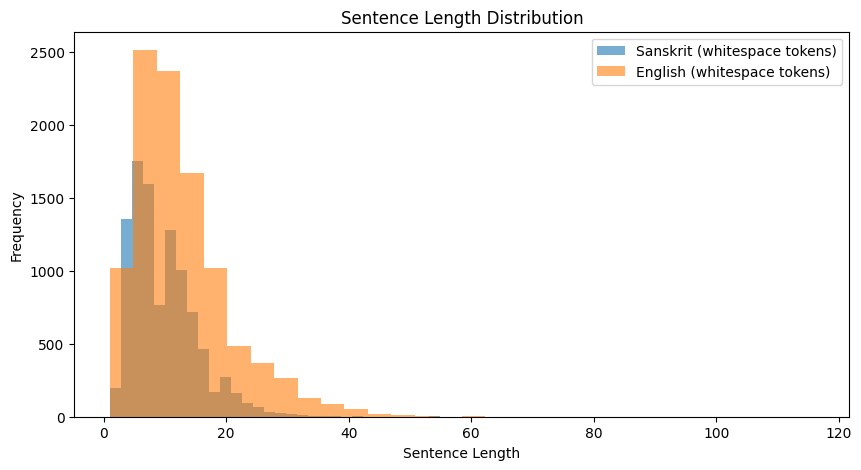

In [9]:
train["sa_len"] = train["sanskrit"].apply(lambda x: len(str(x).split()))
train["en_len"] = train["english"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
plt.hist(train["sa_len"], bins=30, alpha=0.6, label="Sanskrit (whitespace tokens)")
plt.hist(train["en_len"], bins=30, alpha=0.6, label="English (whitespace tokens)")
plt.legend()
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.title("Sentence Length Distribution")
plt.show()

In [10]:
def clean_sanskrit(sentence):
    sentence = str(sentence).strip()
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence

def clean_english(sentence):
    sentence = str(sentence).lower().strip()
    sentence = re.sub(r"\s+", " ", sentence)
    return sentence

In [11]:
train["sanskrit"] = train["sanskrit"].apply(clean_sanskrit)
train["english"] = train["english"].apply(clean_english)

dev["sanskrit"] = dev["sanskrit"].apply(clean_sanskrit)
dev["english"] = dev["english"].apply(clean_english)

test["sanskrit"] = test["sanskrit"].apply(clean_sanskrit)
if HAS_TEST_GOLD:
    test["english"] = test["english"].apply(clean_english)

In [12]:
os.makedirs("spm", exist_ok=True)

train["sanskrit"].to_csv("spm/src.txt", index=False, header=False)
train["english"].to_csv("spm/tgt.txt", index=False, header=False)

SRC_VOCAB_SIZE = 4000
TGT_VOCAB_SIZE = 4000

spm.SentencePieceTrainer.Train(
    input="spm/src.txt", model_prefix="spm/src", vocab_size=SRC_VOCAB_SIZE,
    model_type="bpe", character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)

spm.SentencePieceTrainer.Train(
    input="spm/tgt.txt", model_prefix="spm/tgt", vocab_size=TGT_VOCAB_SIZE,
    model_type="bpe", character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3
)

src_sp = spm.SentencePieceProcessor(model_file="spm/src.model")
tgt_sp = spm.SentencePieceProcessor(model_file="spm/tgt.model")

PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3
SRC_VOCAB_SIZE = src_sp.get_piece_size()
TGT_VOCAB_SIZE = tgt_sp.get_piece_size()

print("Source vocabulary size:", SRC_VOCAB_SIZE)
print("Target vocabulary size:", TGT_VOCAB_SIZE)

Source vocabulary size: 4000
Target vocabulary size: 4000


In [13]:
def encode_source(sentence):
    return src_sp.encode(sentence, out_type=int) + [EOS_IDX]

def encode_target(sentence):
    return [SOS_IDX] + tgt_sp.encode(sentence, out_type=int) + [EOS_IDX]

def prediction_to_sentence(sequence):
    ids = []
    for token in sequence:
        if token == EOS_IDX:
            break
        if token in (PAD_IDX, SOS_IDX):
            continue
        ids.append(token)
    return tgt_sp.decode(ids)

example = train.iloc[0]["english"]
print("Original :", example)
print("Pieces   :", tgt_sp.encode(example, out_type=str))
print("Decoded  :", prediction_to_sentence(encode_target(example)))

Original : save it with ctrl, s.
Pieces   : ['▁save', '▁it', '▁with', '▁ctrl', ',', '▁s', '.']
Decoded  : save it with ctrl, s.


In [14]:

src_lens = train["sanskrit"].apply(lambda x: len(encode_source(x)))
tgt_lens = train["english"].apply(lambda x: len(encode_target(x)))

MAX_SRC_LEN = int(np.percentile(src_lens, 98))
MAX_TGT_LEN = int(np.percentile(tgt_lens, 98))

print("98th percentile source length (subword tokens):", MAX_SRC_LEN)
print("98th percentile target length (subword tokens):", MAX_TGT_LEN)
print("Raw max source/target length was:", src_lens.max(), "/", tgt_lens.max())

def _within_len(df):
    keep = df["sanskrit"].apply(lambda x: len(encode_source(x)) <= MAX_SRC_LEN) & \
           df["english"].apply(lambda x: len(encode_target(x)) <= MAX_TGT_LEN)
    return df[keep].reset_index(drop=True)

before = len(train)
train = _within_len(train)
dev = _within_len(dev) if "english" in dev.columns else dev
print(f"Dropped {before - len(train)} outlier-length training sentences ({len(train)} remain).")


98th percentile source length (subword tokens): 57
98th percentile target length (subword tokens): 51
Raw max source/target length was: 165 / 188
Dropped 277 outlier-length training sentences (9723 remain).


In [15]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, has_target=True):
        self.df = dataframe
        self.has_target = has_target

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        src_ids = torch.tensor(encode_source(self.df.iloc[idx]["sanskrit"]))
        if self.has_target:
            tgt_ids = torch.tensor(encode_target(self.df.iloc[idx]["english"]))
            return src_ids, tgt_ids
        return src_ids

In [16]:
def pad_sequences(batch):
    src_batch = [item[0] for item in batch]
    tgt_batch = [item[1] for item in batch]

    src_batch = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_IDX)

    return src_batch, tgt_batch

In [17]:
train_dataset = TranslationDataset(train, has_target=True)
dev_dataset = TranslationDataset(dev, has_target=True)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=pad_sequences)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=pad_sequences)

print(len(train_dataset), len(dev_dataset))
print(len(train_loader), len(dev_loader))

9723 969
304 31


In [18]:
src_batch, tgt_batch = next(iter(train_loader))
print("Source batch shape:", src_batch.shape)
print("Target batch shape:", tgt_batch.shape)

Source batch shape: torch.Size([32, 51])
Target batch shape: torch.Size([32, 43])


In [19]:
EMBEDDING_DIM = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 2
DROPOUT = 0.4

print("Src vocab:", SRC_VOCAB_SIZE, "| Tgt vocab:", TGT_VOCAB_SIZE)

Src vocab: 4000 | Tgt vocab: 4000


In [20]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, hidden_size, num_layers, dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, embedding_dim, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.hidden_fc = nn.Linear(hidden_size * 2, hidden_size)
        self.cell_fc = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))

        lengths = (src != PAD_IDX).sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )

        outputs, (hidden, cell) = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)

        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        cell = torch.cat((cell[-2], cell[-1]), dim=1)

        hidden = torch.tanh(self.hidden_fc(hidden))
        cell = torch.tanh(self.cell_fc(cell))

        return outputs, hidden.unsqueeze(0), cell.unsqueeze(0)

In [21]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 3, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.size(1)
        hidden = hidden.repeat(src_len, 1, 1).permute(1, 0, 2)

        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)

        return torch.softmax(attention, dim=1)

In [22]:
class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, hidden_size, dropout):
        super().__init__()

        self.embedding = nn.Embedding(output_dim, embedding_dim, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.attention = BahdanauAttention(hidden_size)

        self.lstm = nn.LSTM(
            embedding_dim + hidden_size * 2, hidden_size,
            num_layers=1, batch_first=True
        )

        self.fc = nn.Linear(hidden_size * 3, output_dim)

    def forward(self, input_token, hidden, cell, encoder_outputs):
        input_token = input_token.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_token))

        attention = self.attention(hidden[-1], encoder_outputs).unsqueeze(1)
        context = torch.bmm(attention, encoder_outputs)

        lstm_input = torch.cat((embedded, context), dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        prediction = self.fc(torch.cat((output.squeeze(1), context.squeeze(1)), dim=1))

        return prediction, hidden, cell

In [23]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, source, target, teacher_force_ratio=0.5):
        batch_size = source.shape[0]
        target_len = target.shape[1]
        vocab_size = TGT_VOCAB_SIZE

        outputs = torch.zeros(batch_size, target_len, vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(source)

        input_token = target[:, 0]

        for t in range(1, target_len):
            prediction, hidden, cell = self.decoder(input_token, hidden, cell, encoder_outputs)
            outputs[:, t] = prediction

            best_guess = prediction.argmax(1)
            teacher_force = random.random() < teacher_force_ratio
            input_token = target[:, t] if teacher_force else best_guess

        return outputs

In [24]:
encoder = Encoder(SRC_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, NUM_LAYERS, DROPOUT)
decoder = Decoder(TGT_VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_SIZE, DROPOUT)

model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(4000, 256, padding_idx=0)
    (dropout): Dropout(p=0.4, inplace=False)
    (lstm): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
    (hidden_fc): Linear(in_features=1024, out_features=512, bias=True)
    (cell_fc): Linear(in_features=1024, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(4000, 256, padding_idx=0)
    (dropout): Dropout(p=0.4, inplace=False)
    (attention): BahdanauAttention(
      (attn): Linear(in_features=1536, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (lstm): LSTM(1280, 512, batch_first=True)
    (fc): Linear(in_features=1536, out_features=4000, bias=True)
  )
)


In [25]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Parameters     :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters     : 23160736
Trainable Parameters : 23160736


In [26]:
src_batch, tgt_batch = next(iter(train_loader))
src_batch, tgt_batch = src_batch.to(DEVICE), tgt_batch.to(DEVICE)

with torch.no_grad():
    out = model(src_batch, tgt_batch)

print("Output shape:", out.shape)

Output shape: torch.Size([32, 41, 4000])


## Section 4 — Training


In [27]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

NUM_EPOCHS = 40           # upper bound
EARLY_STOP_PATIENCE = 5   # stop if val loss
GRADIENT_CLIP = 1.0

best_validation_loss = float("inf")
patience_counter = 0

train_losses = []
validation_losses = []

In [28]:
def train_epoch(model, dataloader, optimizer, criterion, teacher_force_ratio):
    model.train()
    epoch_loss = 0

    progress = tqdm(dataloader, leave=False)

    for source, target in progress:
        source = source.to(DEVICE)
        target = target.to(DEVICE)

        optimizer.zero_grad()

        output = model(source, target, teacher_force_ratio=teacher_force_ratio)

        output = output[:, 1:].reshape(-1, output.shape[-1])
        target_flat = target[:, 1:].reshape(-1)

        loss = criterion(output, target_flat)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_description(f"Loss {loss.item():.4f}")

    return epoch_loss / len(dataloader)

In [29]:
@torch.no_grad()
def evaluate(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    for source, target in dataloader:
        source = source.to(DEVICE)
        target = target.to(DEVICE)

        output = model(source, target, teacher_force_ratio=0.0)

        output = output[:, 1:].reshape(-1, output.shape[-1])
        target_flat = target[:, 1:].reshape(-1)

        loss = criterion(output, target_flat)
        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [30]:
print("=" * 70)
print("Training Started")
print("=" * 70)

start_training = time.time()

for epoch in range(NUM_EPOCHS):

    teacher_force_ratio = max(0.2, 0.5 - epoch * 0.02)

    train_loss = train_epoch(model, train_loader, optimizer, criterion, teacher_force_ratio)
    validation_loss = evaluate(model, dev_loader, criterion)

    scheduler.step(validation_loss)

    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    improved = validation_loss < best_validation_loss

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss      : {train_loss:.4f}")
    print(f"Validation Loss : {validation_loss:.4f}")
    print(f"Teacher Forcing : {teacher_force_ratio:.2f}")

    if improved:
        best_validation_loss = validation_loss
        torch.save(model.state_dict(), "best_model.pt")
        patience_counter = 0
        print("Best model saved.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")

    print("-" * 60)

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping triggered after epoch {epoch+1}.")
        break

end_training = time.time()
print()
print("Training Time :", end_training - start_training, "seconds")

Training Started


Epoch 1/40
Train Loss      : 6.4492
Validation Loss : 6.3871
Teacher Forcing : 0.50
Best model saved.
------------------------------------------------------------


Epoch 2/40
Train Loss      : 6.0213
Validation Loss : 6.2522
Teacher Forcing : 0.48
Best model saved.
------------------------------------------------------------


Epoch 3/40
Train Loss      : 5.7774
Validation Loss : 6.1246
Teacher Forcing : 0.46
Best model saved.
------------------------------------------------------------


Epoch 4/40
Train Loss      : 5.5729
Validation Loss : 6.0447
Teacher Forcing : 0.44
Best model saved.
------------------------------------------------------------


...

Epoch 9/40
Train Loss      : 4.5889
Validation Loss : 5.9721
Teacher Forcing : 0.34
No improvement. Patience: 1/5
------------------------------------------------------------


Epoch 10/40
Train Loss      : 4.3840
Validation Loss : 6.0359
Teacher Forcing : 0.32
No improvement. Patience: 2/5
------------------------------------------------------------


Epoch 11/40
Train Loss      : 4.1709
Validation Loss : 6.0877
Teacher Forcing : 0.30
No improvement. Patience: 3/5
------------------------------------------------------------


Epoch 12/40
Train Loss      : 3.8169
Validation Loss : 6.1139
Teacher Forcing : 0.28
No improvement. Patience: 4/5
------------------------------------------------------------


Epoch 13/40
Train Loss      : 3.6304
Validation Loss : 6.1654
Teacher Forcing : 0.26
No improvement. Patience: 5/5
------------------------------------------------------------
Early stopping triggered after epoch 13.

Training Time : 1028.1956388950348 seconds


In [31]:
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
model.eval()
print("Best checkpoint loaded. Best validation loss:", best_validation_loss)

del optimizer, scheduler
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()

Best checkpoint loaded. Best validation loss: 5.951500631147815


8

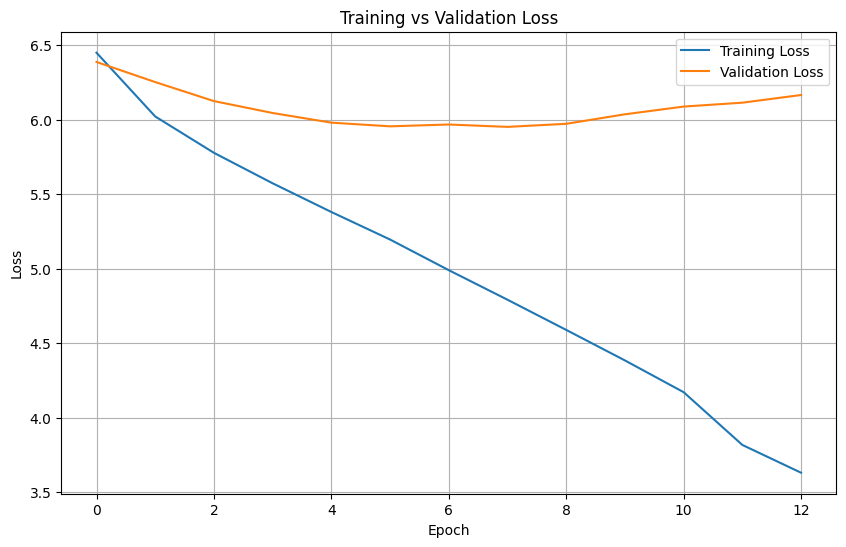

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss")
plt.plot(validation_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
train_perplexity = math.exp(train_losses[-1])
validation_perplexity = math.exp(best_validation_loss)

print("Train Perplexity (last epoch)   :", train_perplexity)
print("Validation Perplexity (best)    :", validation_perplexity)

Train Perplexity (last epoch)   : 37.72713760376812
Validation Perplexity (best)    : 384.3296435768905


## Section 5 — Beam Search, Evaluation, Submission


In [34]:
def beam_search(model, sentence, beam_width=5, max_length=60, length_alpha=0.7):
    model.eval()

    src = torch.tensor([encode_source(sentence)], device=DEVICE)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)

    beams = [([SOS_IDX], 0.0, hidden, cell)]
    completed = []

    def normalized_score(seq, score):
        return score / (len(seq) ** length_alpha)

    for _ in range(max_length):
        candidates = []

        for seq, score_, h, c in beams:
            if seq[-1] == EOS_IDX:
                completed.append((seq, score_))
                continue

            decoder_input = torch.tensor([seq[-1]], device=DEVICE)

            with torch.no_grad():
                prediction, new_hidden, new_cell = model.decoder(
                    decoder_input, h, c, encoder_outputs
                )

            probs = torch.log_softmax(prediction, dim=1)
            values, indices = torch.topk(probs, beam_width)

            for value, index in zip(values[0], indices[0]):
                candidates.append(
                    (seq + [index.item()], score_ + value.item(), new_hidden, new_cell)
                )

        if not candidates:
            break

        beams = sorted(
            candidates, key=lambda x: normalized_score(x[0], x[1]), reverse=True
        )[:beam_width]

    if not completed:
        completed = beams

    best = max(completed, key=lambda x: normalized_score(x[0], x[1]))
    return best[0]

In [35]:
def translate(sentence):
    prediction = beam_search(model, sentence, beam_width=5)
    return prediction_to_sentence(prediction)

# manual check
for i in range(3):
    src = dev.iloc[i]["sanskrit"]
    ref = dev.iloc[i]["english"]
    pred = translate(src)
    print("SRC :", src)
    print("REF :", ref)
    print("PRED:", pred)
    print("-" * 60)

SRC : ते वीराः ।
REF : those are brave men.
PRED: those two are creeses.
------------------------------------------------------------
SRC : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
REF : infinite loop can cause the system to become unresponsive.
PRED: a function to print the function of using the function.
------------------------------------------------------------
SRC : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
REF : "and they spit upon him, and took the reed, and smote him on the head."
PRED: "and when he had passed,, and, and, and, and and the."."
------------------------------------------------------------


In [36]:
# BLEU on dev set
references = []
predictions = []

for i in tqdm(range(len(dev))):
    source = dev.iloc[i]["sanskrit"]
    target = dev.iloc[i]["english"]

    prediction = translate(source)

    references.append([target.split()])
    predictions.append(prediction.split())

bleu = corpus_bleu(references, predictions, smoothing_function=SmoothingFunction().method1)
print("Dev BLEU Score :", bleu)

100%|██████████| 969/969 [03:32<00:00,  4.56it/s]

Dev BLEU Score : 0.054470827559144404


In [37]:
# BERTScore on dev set
reference_sentences = list(dev["english"])
predicted_sentences = [translate(s) for s in dev["sanskrit"]]

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

try:
    P, R, F1 = score(
        predicted_sentences, reference_sentences,
        lang="en", rescale_with_baseline=True,
        batch_size=32, device=DEVICE
    )
except torch.cuda.OutOfMemoryError:
    print("GPU OOM during BERTScore — retrying on CPU (slower).")
    torch.cuda.empty_cache()
    P, R, F1 = score(
        predicted_sentences, reference_sentences,
        lang="en", rescale_with_baseline=True,
        batch_size=32, device="cpu"
    )

print("Dev BERTScore F1:", F1.mean().item())

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dev BERTScore F1: 0.18586845695972443


In [38]:
if HAS_TEST_GOLD:
    test_references = [[t.split()] for t in test["english"]]
    test_predictions = [translate(s).split() for s in test["sanskrit"]]

    test_bleu = corpus_bleu(test_references, test_predictions, smoothing_function=SmoothingFunction().method1)
    print("Test BLEU Score:", test_bleu)

    test_pred_sents = [" ".join(p) for p in test_predictions]

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    try:
        P, R, F1_test = score(
            test_pred_sents, list(test["english"]),
            lang="en", rescale_with_baseline=True,
            batch_size=32, device=DEVICE
        )
    except torch.cuda.OutOfMemoryError:
        print("GPU OOM during BERTScore — retrying on CPU (slower).")
        torch.cuda.empty_cache()
        P, R, F1_test = score(
            test_pred_sents, list(test["english"]),
            lang="en", rescale_with_baseline=True,
            batch_size=32, device="cpu"
        )

    print("Test BERTScore F1:", F1_test.mean().item())
else:
    print("test_en.csv not available — skipping test-set BLEU/BERTScore (dev-set scores above still apply).")

Test BLEU Score: 0.05648299868240478


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Test BERTScore F1: 0.17159844934940338


In [39]:
start = time.time()

translations = []
for i, sentence in enumerate(test["sanskrit"]):
    translations.append(translate(sentence))
    if DEVICE.type == "cuda" and i % 200 == 0:
        torch.cuda.empty_cache()

end = time.time()

inference_time = end - start
parameters = sum(p.numel() for p in model.parameters())

print("Inference Time :", inference_time, "seconds")
print("Total Parameters :", parameters)

Inference Time : 217.9990930557251 seconds
Total Parameters : 23160736


In [40]:
examples = []
n_examples = min(10, len(test))

for i in range(n_examples):
    source = test.iloc[i]["sanskrit"]
    prediction = translations[i]
    reference = test.iloc[i]["english"] if HAS_TEST_GOLD else None

    examples.append({
        "Sanskrit": source,
        "Reference": reference,
        "Prediction": prediction
    })

examples_df = pd.DataFrame(examples)
examples_df

,Sanskrit,Reference,Prediction
0,एक्लिप्स् इति प्रोग्रामर् कृते दोषान्वेषणे अपि...,eclipse also helps the programmer to find out ...,we can also write a java program and and and a...
1,विश्वासकारणादेव समभाषि मया वचः। इति यथा शास्त्...,"""we having the same spirit of faith, according...","""and i have i in the, of the, of the lord, and..."
2,"तदा, तत्स्वयं ड्रैवर निमित्तम् अन्वेष्यति। अहं...",then it will automatically begin searching for...,"then, i will go into the first.. click on it. ..."
3,"सर्वेभ्यः इटरेशन्-अर्थम्, iterator इतीदं प्रत्...",the iterator will be set to each of the indice...,the first fields of the first fields of the st...
4,अपरं द्वितीयमुद्रायां तेन मोचितायां द्वितीयस्य...,"""and when he had opened the second seal, i hea...","""and when he had called the, of the,, the,,,,,..."
5,"वयम्, ओब्जेक्ट्स् स्वकीयान् स्थितीन् फील्ड्स् ...",we know that objects store their individual st...,"we, we have learnt how to identify the the.."
6,बाल: युष्मासु विश्वासं करोति ।,boy has belief on you all.,child has kindness on you all.
7,प्रकृति का अवलोकन करने से आप आश्चर्य चकित हो स...,observing the nature helps create a sense of w...,it helps to be used for of and and.
8,यूयं कीदृक् तस्याज्ञा अपालयत भयकम्पाभ्यां तं ग...,"""and his inward affection is more abundant tow...","""and when the,,,, the,, and the,, and the,, an..."
9,"""वर्षाया: जलस्य कश्चन अंश: भूमौ शुष्को भूत्वा ...",a part of rain water is absorbedby earth. wate...,"""this is also used in the one of, in one,, one..."


In [41]:
submission = pd.DataFrame({
    "Source_id": test["id"],
    "Sentence_en": translations
})

submission.to_csv("submission.csv", index=False, encoding="utf-8")
submission.head()

,Source_id,Sentence_en
0,1,we can also write a java program and and and a...
1,2,"""and i have i in the, of the, of the lord, and..."
2,3,"then, i will go into the first.. click on it. ..."
3,4,the first fields of the first fields of the st...
4,5,"""and when he had called the, of the,, the,,,,,..."
